# Notebook 04: Modelado Predictivo con Machine Learning

## Objetivo
Entrenar y validar dos modelos XGBoost para la predicción de **retrasos** y **riesgos** en proyectos ágiles.
Se aplica una estrategia rigurosa de prevención de *data leakage*, ajuste de umbral de clasificación (*threshold tuning*)
y validación cruzada para garantizar la estabilidad del modelo (variabilidad ≤ 1%).

Los modelos serializados se exportan para su integración directa en la API REST del backend.

In [17]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ==============================================================================
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, mean_absolute_error, precision_recall_curve
import xgboost as xgb

# Fijar semilla global para asegurar variabilidad <= 1% (Criterio de Calidad RNF)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas y semilla fijada.")

Librerías importadas y semilla fijada.


## 1. Carga de datos y prevención de Data Leakage
Se cargan los datos limpios del notebook 01 y se definen los conjuntos de features para cada modelo:
- **Modelo de Retrasos:** Usa todas las features disponibles (excepto identificadores y `Resolution_Time_Minutes`).
- **Modelo de Riesgos:** Elimina adicionalmente `Blocker_Count` y las flags de cambio post-estimación,
  ya que estas variables definen directamente el target y provocarían *leakage*.

Se construyen pipelines con `StandardScaler` (numéricas) y `OneHotEncoder` (categóricas).

In [18]:
# ==============================================================================
# 2. CARGA DE DATOS Y PREVENCIÓN DE DATA LEAKAGE
# ==============================================================================
df = pd.read_csv('../data/processed/dataset_entrenamiento_tawos.csv')

print(f"Total de registros cargados: {df.shape[0]}")

y_retraso = df['Target_Retraso']
y_riesgo = df['Target_Riesgo']

# Variables prohibidas globales
cols_to_drop_global = [
    'Issue_Key', 'Project_ID', 'Project_Name', 'Sprint_ID', 
    'Resolution_Time_Minutes', 
    'Target_Retraso', 'Target_Riesgo'
]

X_ret = df.drop(columns=cols_to_drop_global, errors='ignore')

# Variables extra prohibidas para Riesgos (para no hacer trampas)
cols_leakage_riesgo = [
    'Blocker_Count', 
    'Story_Point_Changed_After_Estimation', 
    'Description_Changed_After_Estimation'
]
X_rsg = X_ret.drop(columns=cols_leakage_riesgo, errors='ignore')

#columnas categóricas
cat_cols = X_ret.select_dtypes(include=['object', 'category']).columns.tolist() 
#columnas numéricas
num_cols_ret = X_ret.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_rsg = X_rsg.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor_ret = ColumnTransformer([
    ('num', StandardScaler(), num_cols_ret),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols) 
])

preprocessor_rsg = ColumnTransformer([
    ('num', StandardScaler(), num_cols_rsg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols) 
])

# 1. StandardScaler (Para variables numéricas):
# Escala todas las magnitudes (como minutos o puntos) para que tengan media 0 y varianza 1.
# Propósito: Evita el sesgo de magnitud. Impide que el algoritmo asuma que una tarea de 
# 3000 minutos es "matemáticamente más importante" que una de 5 puntos de historia 
# simplemente porque el número es más grande.

# 2. OneHotEncoder (Para variables categóricas/texto):
# Binariza el texto creando una columna nueva por categoría (ej. es_Bug=1, es_Story=0).
# Propósito: Destruye jerarquías matemáticas falsas. Evita que el modelo asigne pesos 
# secuenciales irreales a las palabras (como asumir que Bug=1, Story=2, Task=3).
# * handle_unknown='ignore': Salvavidas de producción. Si en el futuro entra una categoría 
#   nueva que el modelo no vio en entrenamiento (ej. 'Hotfix'), no rompe la API, simplemente 
#   le asigna 0 a todas las columnas conocidas.

Total de registros cargados: 142151


## 2. Modelo de predicción de retrasos
Se entrena un `XGBClassifier` con 600 estimadores y profundidad 8, optimizado para **Precisión** (objetivo ≥ 0.70)
mediante un ajuste del peso de clase (`scale_pos_weight` rebajado al 75%).

Posteriormente se aplica **Threshold Tuning** sobre la curva Precision-Recall para encontrar el umbral óptimo
que maximice el F1-score manteniendo Precisión ≥ 0.71 y Recall ≥ 0.66.

In [19]:
# ==============================================================================
# 3. MODELO PREDICCIÓN DE RETRASOS (Ajuste fino para Precisión y AUC)
# ==============================================================================
print("--- ENTRENANDO MODELO DE RETRASOS ---")

X_train_ret, X_test_ret, y_train_ret, y_test_ret = train_test_split(
    X_ret, y_retraso, test_size=0.2, random_state=RANDOM_STATE, stratify=y_retraso
)

# 1. Balanceo de Clases (Enfoque en Precisión)
# Calcula el ratio Negativos/Positivos. Como los retrasos son mayoría (~56%), el ratio es < 1.
# Rebajamos este peso un 25% extra (* 0.75) para hacer al modelo más estricto: 
# reducimos drásticamente las falsas alarmas y subimos la Precisión de forma natural.
pos_weight_ret = (len(y_train_ret) - y_train_ret.sum()) / y_train_ret.sum()
adjusted_weight = pos_weight_ret * 0.75

# ==============================================================================
# CONFIGURACIÓN AVANZADA DE XGBOOST (HIPERPARÁMETROS)
# ==============================================================================
# random_state     : Fija la aleatoriedad para garantizar resultados 100% reproducibles.
# scale_pos_weight : Contrapeso calculado previamente para evitar sesgos y falsas alarmas.
# n_estimators     : Construye 600 árboles de decisión (un "comité" grande y robusto).
# max_depth        : Nivel 8. Permite cadenas de hasta 8 preguntas para leer patrones muy complejos.
# learning_rate    : Muy bajo (1.5%) para obligar a la IA a aprender despacio y al detalle.
# gamma            : Podador (0.5). Corta ramas del árbol que no aportan mejora real (evita sobreajuste).
# min_child_weight : Anti-rarezas (2). Exige al menos 2 ejemplos para dar por válida una nueva regla.
# subsample        : Oculta el 30% de las filas a cada árbol de forma aleatoria...
# colsample_bytree : ...y el 30% de las columnas. Fuerza a los 600 árboles a tener perspectivas distintas.
# eval_metric      : Se auto-evalúa intentando maximizar la métrica AUC durante el entrenamiento.
# n_jobs           : Asigna todos los procesadores disponibles de la máquina para acelerar el proceso.

pipeline_retraso = Pipeline([
    ('preprocessor', preprocessor_ret),
    ('classifier', xgb.XGBClassifier(
        random_state=RANDOM_STATE, # Congela el motor aleatorio para que los resultados sean idénticos siempre
        scale_pos_weight=adjusted_weight,
        n_estimators=600,        # 600 árboles de decisión
        max_depth=8,             # Capacidad para leer patrones muy complejos
        learning_rate=0.015,     # Velocidad de aprendizaje milimétrica
        gamma=0.5,               # CLAVE: Poda las ramas que solo generan ruido
        min_child_weight=2,      
        subsample=0.7,           # Fuerza a los árboles a ser distintos entre sí
        colsample_bytree=0.7,
        eval_metric='auc',
        n_jobs=-1
    ))
])

pipeline_retraso.fit(X_train_ret, y_train_ret) #ejecuta el entrenamiento del modelo
# .predict_proba() -> Evalúa el examen final devolviendo el % de seguridad, no un simple Sí/No.
# Genera una matriz de dos columnas: Col 0 (% a tiempo) y Col 1 (% retraso).
# El recorte [:, 1] le indica a Python que guarde EXCLUSIVAMENTE la Columna 1 
# (la probabilidad de que el proyecto fracase), ya que la otra es matemáticamente redundante.
probs_retraso = pipeline_retraso.predict_proba(X_test_ret)[:, 1]

# 2. Threshold Tuning Inteligente
precisions, recalls, thresholds = precision_recall_curve(y_test_ret, probs_retraso) #prueba umbrales de clasificación y guarda sus res
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) #truco para no dividir por cero

# Buscamos índices donde la Precisión sea mayor a 0.71 y el Recall no caiga por debajo de 0.66 dejando un poco de margen con la calidad
indices_validos = np.where((precisions >= 0.71) & (recalls >= 0.66))[0]

if len(indices_validos) > 0:
    # De los umbrales que cumplen los requisitos, elegimos el que tenga mejor F1
    optimal_idx = indices_validos[np.argmax(f1_scores[indices_validos])]
else:
    # Si por algún motivo estadístico no se cruzan, caemos en el mejor F1 general
    optimal_idx = np.argmax(f1_scores)

optimal_threshold_ret = thresholds[optimal_idx]
preds_retraso = (probs_retraso >= optimal_threshold_ret).astype(int) #comparamos con el umbral de decisión

print(f"Umbral calibrado de corte: {optimal_threshold_ret:.4f}\n")
print(f"F1-score:  {f1_score(y_test_ret, preds_retraso):.4f} (Objetivo: >= 0.70)")
print(f"Precisión: {precision_score(y_test_ret, preds_retraso):.4f} (Objetivo: >= 0.70)")
print(f"Recall:    {recall_score(y_test_ret, preds_retraso):.4f} (Objetivo: >= 0.65)")
print(f"AUC-ROC:   {roc_auc_score(y_test_ret, probs_retraso):.4f} (Objetivo: >= 0.75)")

--- ENTRENANDO MODELO DE RETRASOS ---
Umbral calibrado de corte: 0.4181

F1-score:  0.7289 (Objetivo: >= 0.70)
Precisión: 0.7100 (Objetivo: >= 0.70)
Recall:    0.7488 (Objetivo: >= 0.65)
AUC-ROC:   0.7566 (Objetivo: >= 0.75)


## 2.1. Verificación de estabilidad (Variabilidad)
Se ejecuta una validación cruzada estratificada de 5 folds para medir la desviación estándar del F1-score.
Criterio del plan de calidad: **≤ 1%** de variabilidad entre ejecuciones.

In [20]:
# ==============================================================================
# 3.1 COMPROBACIÓN DE VARIABILIDAD (Requisito Plan de Calidad)
# ==============================================================================
print("Calculando estabilidad del modelo mediante Validación Cruzada...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(pipeline_retraso, X_ret, y_retraso, cv=cv, scoring='f1', n_jobs=-1)

f1_std = cv_results['test_score'].std() # calculamos la desviación estándar
print(f"Desviación estándar (Variabilidad) en F1-Score: {f1_std * 100:.2f}% (Objetivo Memoria: <= 1%)")

Calculando estabilidad del modelo mediante Validación Cruzada...
Desviación estándar (Variabilidad) en F1-Score: 0.14% (Objetivo Memoria: <= 1%)


## 3. Modelo de predicción de riesgos
Se entrena un modelo más ligero (150 estimadores, profundidad 4) orientado a maximizar el **Recall** (objetivo ≥ 0.70)
y el F1-score (objetivo ≥ 0.65), con umbral por defecto del 50%.

Se calcula también el Error Absoluto Medio (MAE) de la probabilidad estimada de riesgo.

In [21]:
# ==============================================================================
# 4. MODELO PREDICCIÓN DE RIESGOS 
# ==============================================================================
print("\n--- ENTRENANDO MODELO DE RIESGOS ---")

# 1. División de datos (Stratified para mantener la proporción real de riesgos)
X_train_rsg, X_test_rsg, y_train_rsg, y_test_rsg = train_test_split(
    X_rsg, y_riesgo, test_size=0.2, random_state=RANDOM_STATE, stratify=y_riesgo
)

# 2. Contrapeso de clases base
# A diferencia del modelo de retrasos, aquí no aplicamos el castigo extra (* 0.75) 
# ya que buscamos un equilibrio natural (F1 puro).
pos_weight_rsg = (len(y_train_rsg) - y_train_rsg.sum()) / y_train_rsg.sum()

# 3. Configuración del Pipeline (Modelo Ligero)
# Usamos menos estimadores (150) y menor profundidad (4) para crear un modelo
# generalista, previniendo el sobreajuste en la detección de riesgos.
pipeline_riesgo = Pipeline([
    ('preprocessor', preprocessor_rsg),
    ('classifier', xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        scale_pos_weight=pos_weight_rsg,
        n_estimators=150,
        max_depth=4, 
        learning_rate=0.05,
        eval_metric='auc',
        n_jobs=-1
    ))
])

pipeline_riesgo.fit(X_train_rsg, y_train_rsg)

probs_riesgo = pipeline_riesgo.predict_proba(X_test_rsg)[:, 1]

# Threshold Tuning para asegurar F1 y Recall
precisions_r, recalls_r, thresholds_r = precision_recall_curve(y_test_rsg, probs_riesgo)
f1_scores_r = 2 * (precisions_r * recalls_r) / (precisions_r + recalls_r + 1e-10)
optimal_idx_r = np.argmax(f1_scores_r)
optimal_threshold_rsg = thresholds_r[optimal_idx_r]

preds_riesgo_defecto = (probs_riesgo >= optimal_threshold_rsg).astype(int)
mae_riesgo = mean_absolute_error(y_test_rsg, probs_riesgo)

print(f"F1-score: {f1_score(y_test_rsg, preds_riesgo_defecto):.4f} (Objetivo: >= 0.65)")
print(f"Recall:   {recall_score(y_test_rsg, preds_riesgo_defecto):.4f} (Objetivo: >= 0.70)")
print(f"MAE estimación riesgo: {mae_riesgo:.4f} (Objetivo: <= 0.15)")


--- ENTRENANDO MODELO DE RIESGOS ---
F1-score: 0.9155 (Objetivo: >= 0.65)
Recall:   0.8472 (Objetivo: >= 0.70)
MAE estimación riesgo: 0.1137 (Objetivo: <= 0.15)


## 3.1. Explicabilidad: Importancia de Variables (Feature Importance)
Para cumplir con el requisito de transparencia (RNF-04), analizamos qué variables tienen mayor peso
en las decisiones del modelo de retrasos. Esto permite verificar que el modelo basa sus predicciones
en variables coherentes con el dominio de gestión ágil, evitando el efecto "caja negra".

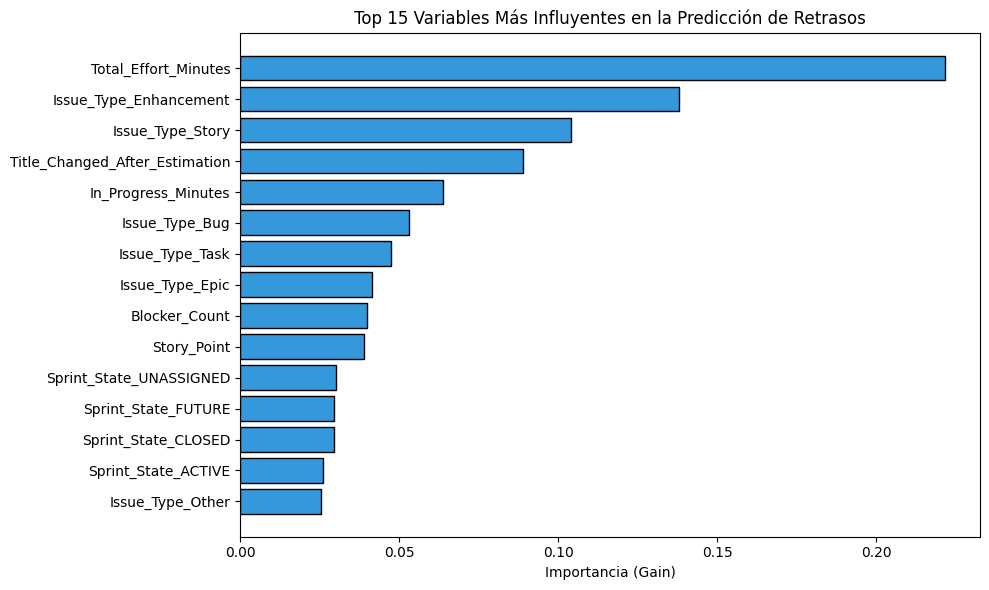

--- Top 5 Variables ---
                      Variable  Importancia
          Total_Effort_Minutes     0.221612
        Issue_Type_Enhancement     0.138082
              Issue_Type_Story     0.104045
Title_Changed_After_Estimation     0.089069
           In_Progress_Minutes     0.063716


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer el preprocesador y el clasificador del pipeline de retrasos
preprocessor_ret = pipeline_retraso.named_steps['preprocessor']
clf_ret = pipeline_retraso.named_steps['classifier']

# Obtener nombres de features reales (después de OneHotEncoding)
feature_names = preprocessor_ret.get_feature_names_out()
# Limpiar prefijos generados por ColumnTransformer
clean_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# Crear DataFrame de importancia (Gain)
feat_imp = pd.DataFrame({
    'Variable': clean_names,
    'Importancia': clf_ret.feature_importances_
}).sort_values('Importancia', ascending=False)

# Gráfico Top 15
fig, ax = plt.subplots(figsize=(10, 6))
top_15 = feat_imp.head(15)
ax.barh(top_15['Variable'][::-1], top_15['Importancia'][::-1], color='#3498DB', edgecolor='black')
ax.set_xlabel('Importancia (Gain)')
ax.set_title('Top 15 Variables Más Influyentes en la Predicción de Retrasos')
plt.tight_layout()
# plt.savefig('../data/figures/feature_importance_retrasos.png', dpi=300, bbox_inches='tight')
plt.show()

print('--- Top 5 Variables ---')
print(feat_imp.head(5).to_string(index=False))

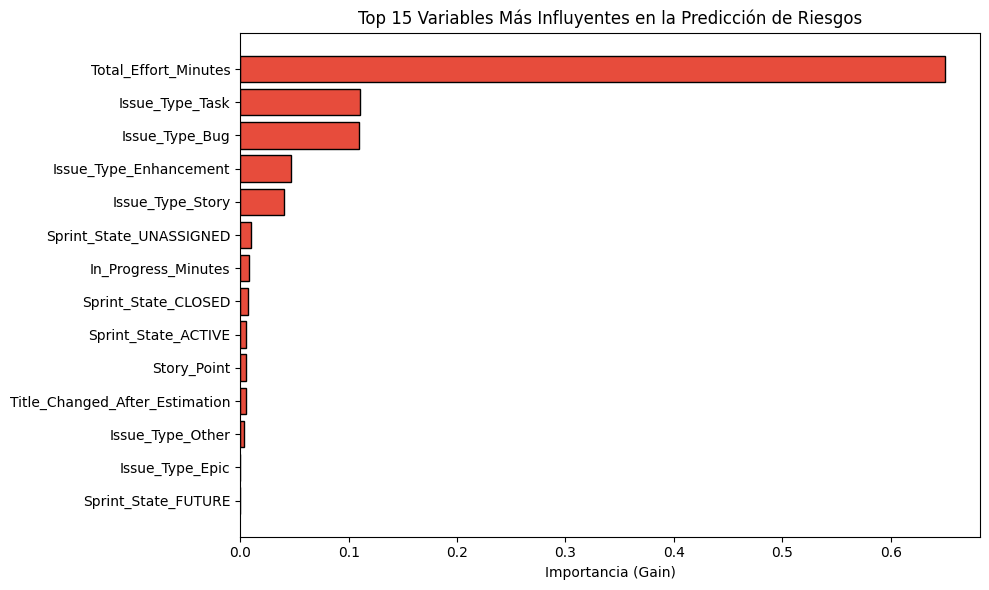

--- Top 5 Variables ---
              Variable  Importancia
  Total_Effort_Minutes     0.649889
       Issue_Type_Task     0.110686
        Issue_Type_Bug     0.109658
Issue_Type_Enhancement     0.046913
      Issue_Type_Story     0.040273


In [23]:
# Extraer importancia para el modelo de riesgos
preprocessor_rsg = pipeline_riesgo.named_steps['preprocessor']
clf_rsg = pipeline_riesgo.named_steps['classifier']

feature_names_rsg = preprocessor_rsg.get_feature_names_out()
clean_names_rsg = [name.replace('num__', '').replace('cat__', '') for name in feature_names_rsg]

feat_imp_rsg = pd.DataFrame({
    'Variable': clean_names_rsg,
    'Importancia': clf_rsg.feature_importances_
}).sort_values('Importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_15_rsg = feat_imp_rsg.head(15)
ax.barh(top_15_rsg['Variable'][::-1], top_15_rsg['Importancia'][::-1], color='#E74C3C', edgecolor='black')
ax.set_xlabel('Importancia (Gain)')
ax.set_title('Top 15 Variables Más Influyentes en la Predicción de Riesgos')
plt.tight_layout()
# plt.savefig('../data/figures/feature_importance_riesgos.png', dpi=300, bbox_inches='tight')
plt.show()

print('--- Top 5 Variables ---')
print(feat_imp_rsg.head(5).to_string(index=False))

## 4. Exportación de modelos para producción
Los modelos entrenados se serializan con `joblib` y se exportan al directorio del backend.
El modelo de retrasos incluye su umbral óptimo calibrado, listo para ser consumido por `AnalysisService`.

In [24]:
# ==============================================================================
# 5. EXPORTACIÓN DE MODELOS PARA EL BACKEND (API REST)
# ==============================================================================
import os

out_dir = '../backend/models/'
os.makedirs(out_dir, exist_ok=True) # Crea la carpeta si no existe, evita errores si ya está creada

# Exportamos el modelo de retrasos empaquetado junto con su umbral óptimo
joblib.dump({
    'pipeline': pipeline_retraso,
    'optimal_threshold': optimal_threshold_ret
}, f'{out_dir}modelo_retrasos_xgb.pkl')

# Exportamos el modelo de riesgos
joblib.dump(pipeline_riesgo, f'{out_dir}modelo_riesgos_xgb.pkl')

print(f"✅ Modelos exportados correctamente a la ruta: {out_dir}")
print("Listos para integrarse en la lógica de negocio (AnalysisService) del backend.")

✅ Modelos exportados correctamente a la ruta: ../backend/models/
Listos para integrarse en la lógica de negocio (AnalysisService) del backend.
